In [0]:
from pyspark.sql.functions import count, desc, avg, round, col
import matplotlib.pyplot as plt
import pandas as pd

df = spark.read.format("delta").load("/Volumes/workspace/default/ ev_charging_data /delta_table")

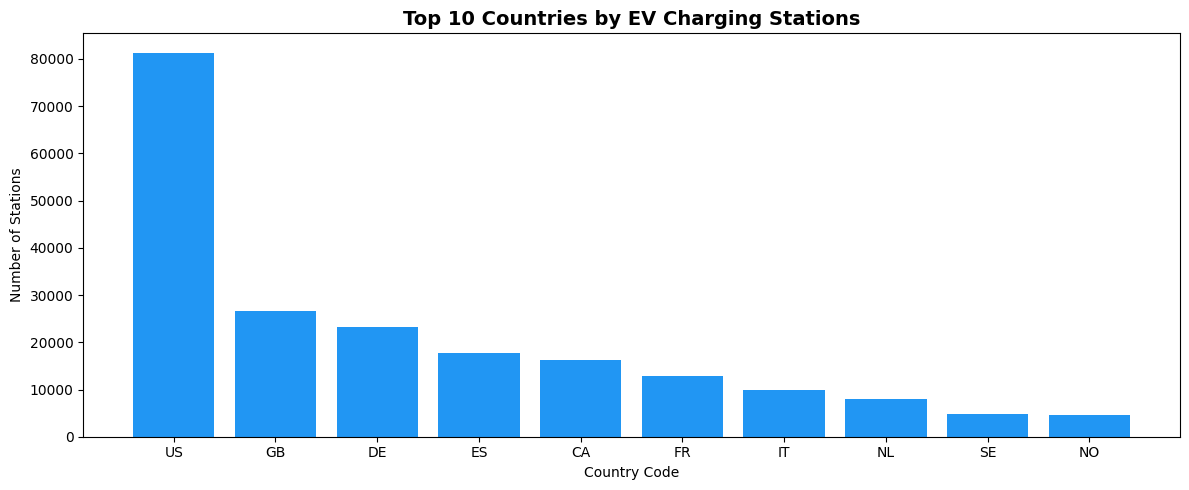

Chart saved.


In [0]:
top_countries = df.groupBy("country_code") \
    .agg(count("id").alias("station_count")) \
    .orderBy(desc("station_count")) \
    .limit(10) \
    .toPandas()

plt.figure(figsize=(12, 5))
plt.bar(top_countries["country_code"], top_countries["station_count"], color="#2196F3")
plt.title("Top 10 Countries by EV Charging Stations", fontsize=14, fontweight="bold")
plt.xlabel("Country Code")
plt.ylabel("Number of Stations")
plt.tight_layout()
plt.savefig("/Volumes/workspace/default/ ev_charging_data /top_countries.png", dpi=150)
plt.show()
print("Chart saved.")

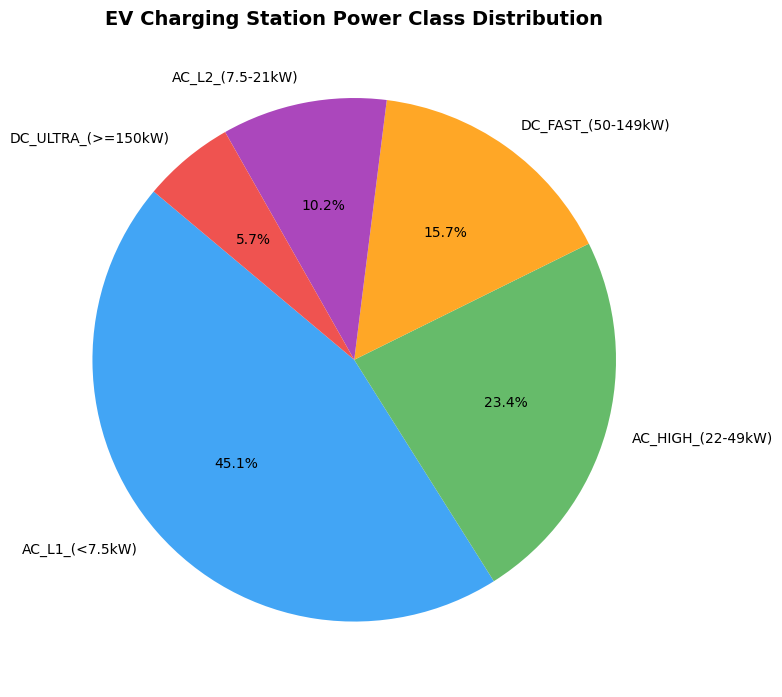

Chart saved.


In [0]:
power_dist = df.groupBy("power_class") \
    .agg(count("id").alias("count")) \
    .orderBy(desc("count")) \
    .toPandas()

colors = ["#42A5F5", "#66BB6A", "#FFA726", "#AB47BC", "#EF5350"]
plt.figure(figsize=(8, 8))
plt.pie(power_dist["count"], labels=power_dist["power_class"], autopct="%1.1f%%", colors=colors, startangle=140)
plt.title("EV Charging Station Power Class Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/Volumes/workspace/default/ ev_charging_data /power_distribution.png", dpi=150)
plt.show()
print("Chart saved.")

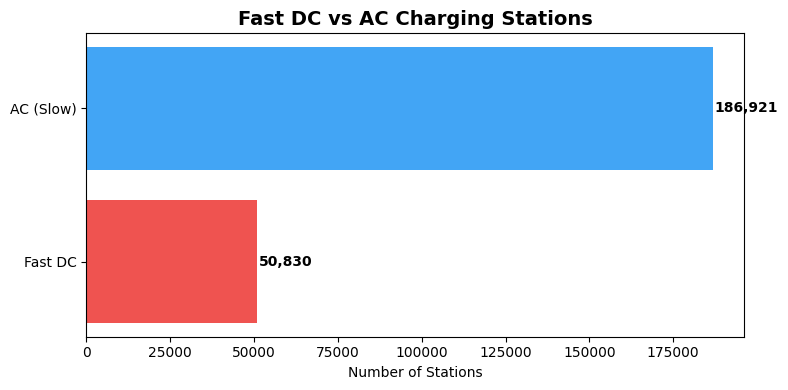

Chart saved.


In [0]:
fast_dc = df.groupBy("is_fast_dc") \
    .agg(count("id").alias("station_count")) \
    .toPandas()

fast_dc["label"] = fast_dc["is_fast_dc"].map({True: "Fast DC", False: "AC (Slow)"})

plt.figure(figsize=(8, 4))
plt.barh(fast_dc["label"], fast_dc["station_count"], color=["#EF5350", "#42A5F5"])
plt.title("Fast DC vs AC Charging Stations", fontsize=14, fontweight="bold")
plt.xlabel("Number of Stations")
for i, v in enumerate(fast_dc["station_count"]):
    plt.text(v + 500, i, f"{v:,}", va="center", fontweight="bold")
plt.tight_layout()
plt.savefig("/Volumes/workspace/default/ ev_charging_data /fast_vs_ac.png", dpi=150)
plt.show()
print("Chart saved.")

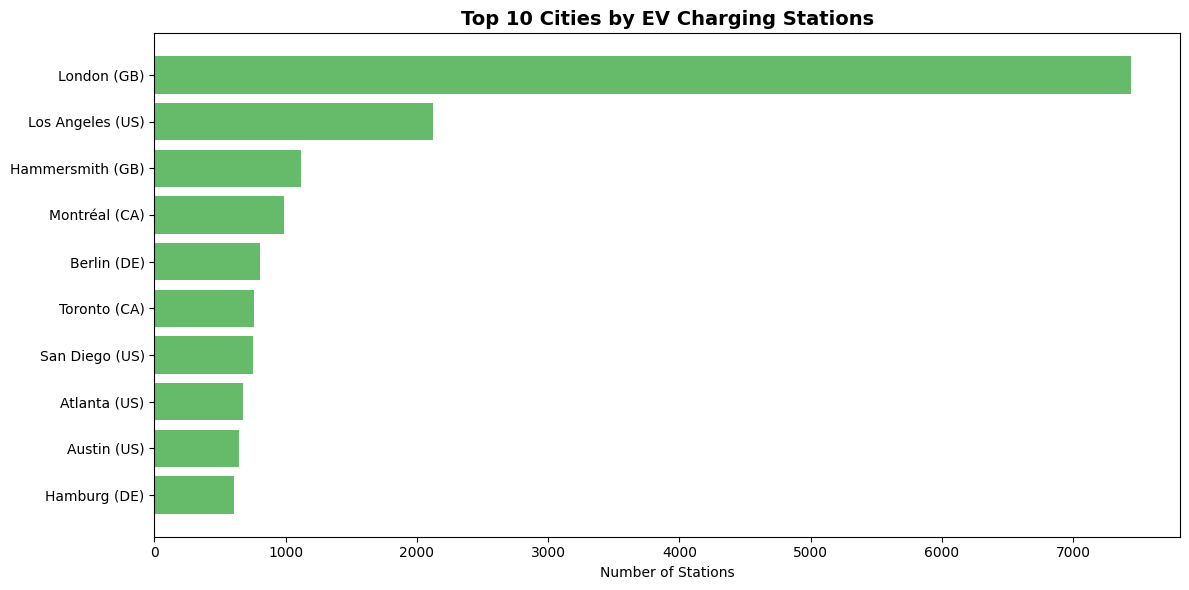

Chart saved.


In [0]:
top_cities = df.filter(col("city") != "Unknown City") \
    .groupBy("city", "country_code") \
    .agg(count("id").alias("station_count")) \
    .orderBy(desc("station_count")) \
    .limit(10) \
    .toPandas()

top_cities["label"] = top_cities["city"] + " (" + top_cities["country_code"] + ")"

plt.figure(figsize=(12, 6))
plt.barh(top_cities["label"][::-1], top_cities["station_count"][::-1], color="#66BB6A")
plt.title("Top 10 Cities by EV Charging Stations", fontsize=14, fontweight="bold")
plt.xlabel("Number of Stations")
plt.tight_layout()
plt.savefig("/Volumes/workspace/default/ ev_charging_data /top_cities.png", dpi=150)
plt.show()
print("Chart saved.")